In [31]:
import sys
sys.path.append("..")
%run "../moduli.py"

In [81]:
pickle_fit = "analisi_singola.pkl"
json_fit = "config_singola.json"

def modello(par, x:np.ndarray):
    return par[0] + par[1] * x
param_labels = ["A", "B"]

# Lettura

Lettura del file Json

In [ ]:
with open(json_fit) as f:
    nomi = json.load(f)

file_input = os.path.join(nomi["cartella"]["input"],nomi["metodi"]["file_input"])

os.makedirs(nomi["cartella"]["output"], exist_ok=True)

dati = let.csv_to_dict(file_input)
x = Misura(dati["x"],dati["sx"])
y = Misura(dati["y"],dati["sy"])
del dati

titolo = f"{nomi['metodi']['titolo']}"
xlabel = param_labels[0]
xunit = ""
ylabel = param_labels[1]
yunit = ""

grafico_output1 = os.path.join(
    nomi["cartella"]["output"],
    "profilazione_3d.jpg"
)
grafico_output2 = os.path.join(
    nomi["cartella"]["output"],
    "profilazione_2d.jpg"
)

Lettura del file Pickle

In [ ]:
a = Misura(None, None)
b = Misura(None, None)
anal = let.importa_pickle(pickle_fit)
[[a.val, b.val], [a.s, b.s]]  = anal
del anal

# Creazione $\chi^2$

In [46]:
def chi2(params, x:Misura, y:Misura):
    y_model = modello(params, x.val)
    return np.sum(((y.val - y_model) / y.s) ** 2)

In [58]:
densita = 50
larghezza = 2

a_range = np.linspace(a.val - larghezza*a.s, a.val + larghezza*a.s, densita)
b_range = np.linspace(b.val - larghezza*b.s, b.val + larghezza*b.s, densita)

In [55]:
import itertools

coords = np.array(list(itertools.product(a_range, b_range)))
CHI = np.array([chi2(c, x, y) for c in coords])

CHI = CHI.reshape(len(a_range), len(b_range))

In [60]:
from scipy.optimize import minimize

def profilazione_2_to_1(x, y, parametri_range, modello, indici, beta0):

    def chi2(params):
        y_model = modello(params, x.val)
        return np.sum(((y.val - y_model) / y.s) ** 2)

    n = len(parametri_range)
    beta0 = np.array(beta0)

    # --------------------------------------------------
    # parametro che rimane (A)
    # --------------------------------------------------
    profile_range = parametri_range[indici[0]]  # SOLO 1 parametro profilo

    results = []

    free_idx = [i for i in range(n) if i not in indici]

    for A_val in profile_range:

        def objective(free_params):

            full_params = beta0.copy()

            # fisso A
            full_params[indici[0]] = A_val

            # metto free params
            for i, val in zip(free_idx, free_params):
                full_params[i] = val

            return chi2(full_params)

        # inizializzazione
        if len(free_idx) > 0:
            x_init = beta0[free_idx]
            res = minimize(objective, x_init, method="L-BFGS-B")
            results.append(res.fun)
        else:
            results.append(objective([]))

    return np.array(results)

In [61]:
Z_B = profilazione_2_to_1(x, y, [a_range, b_range], modello, indici=[1], beta0=[a.val, b.val])
Z_A = profilazione_2_to_1(x, y, [a_range, b_range], modello, indici=[0], beta0=[a.val, b.val])

# Grafici

Range del grafico

In [56]:
zoom = 0.5

da = np.max(a_range) - np.min(a_range)
db = np.max(b_range) - np.min(b_range)
dchi = np.max(CHI) - np.min(CHI)
xlim = (np.min(a_range) - zoom * da,
np.max(a_range) + zoom * da)
ylim = (np.min(b_range) - zoom * db,
np.max(b_range) + zoom * db)
zlim = (np.min(CHI) - zoom * dchi,
np.max(CHI) + zoom * dchi)

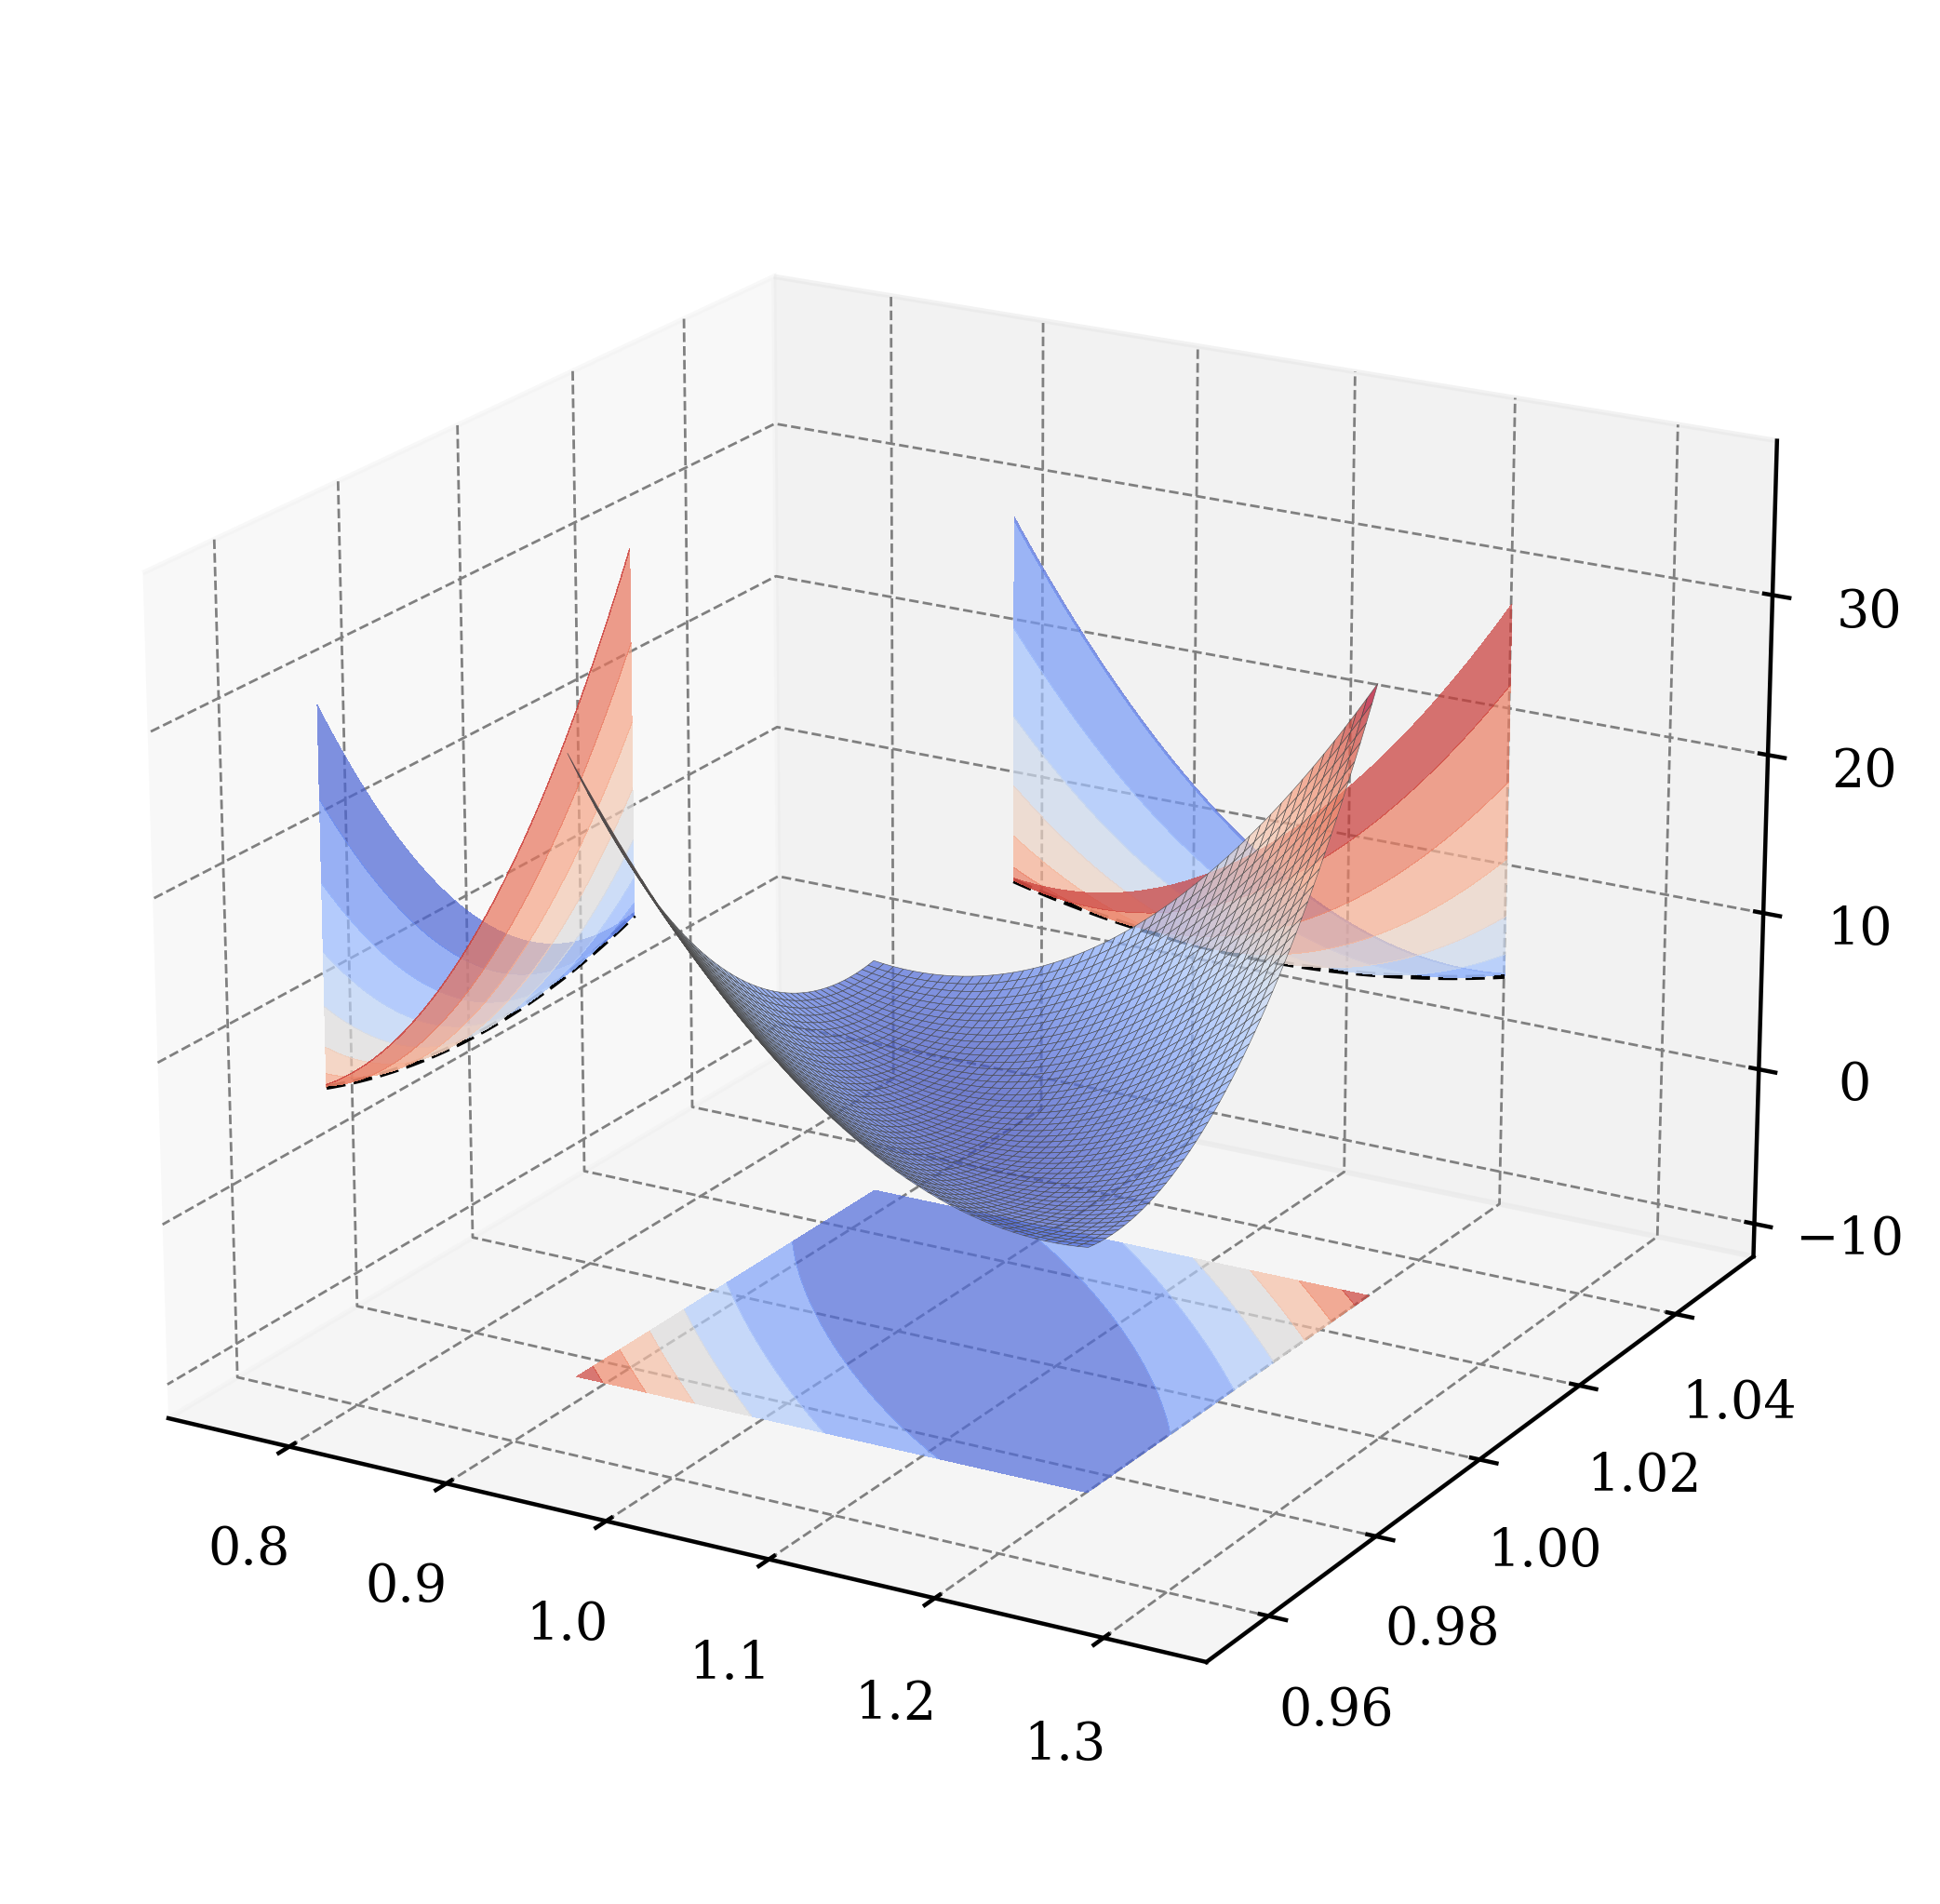

In [ ]:
A,B = np.meshgrid(a_range, b_range)

# Creazione del grafico 3D
fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(1,1,1, projection='3d')
ax.view_init(elev=20, azim=-60)
ax.set(xlim=xlim, ylim=ylim, zlim=zlim)

# Elementi del grafico
ax.plot_surface(A, B, CHI, cmap='coolwarm', edgecolor='0.3', linewidth=0.1, alpha=0.7)
ax.contourf(A, B, CHI, zdir='x', offset=xlim[0], cmap='coolwarm', alpha=0.7)
ax.contourf(A, B, CHI, zdir='y', offset=ylim[1], cmap='coolwarm', alpha=0.7)
ax.contourf(A, B, CHI, zdir='z', offset=zlim[0], cmap='coolwarm', alpha=0.7)
ax.plot(a_range, Z_B, zs=ylim[1], zdir='y', color='black', linewidth=1, linestyle="--")
ax.plot(b_range, Z_A, zs=xlim[0], zdir='x', color='black', linewidth=1, linestyle="--")

# Salvataggio del grafico
let.salva_grafico(fig, grafico_output1)

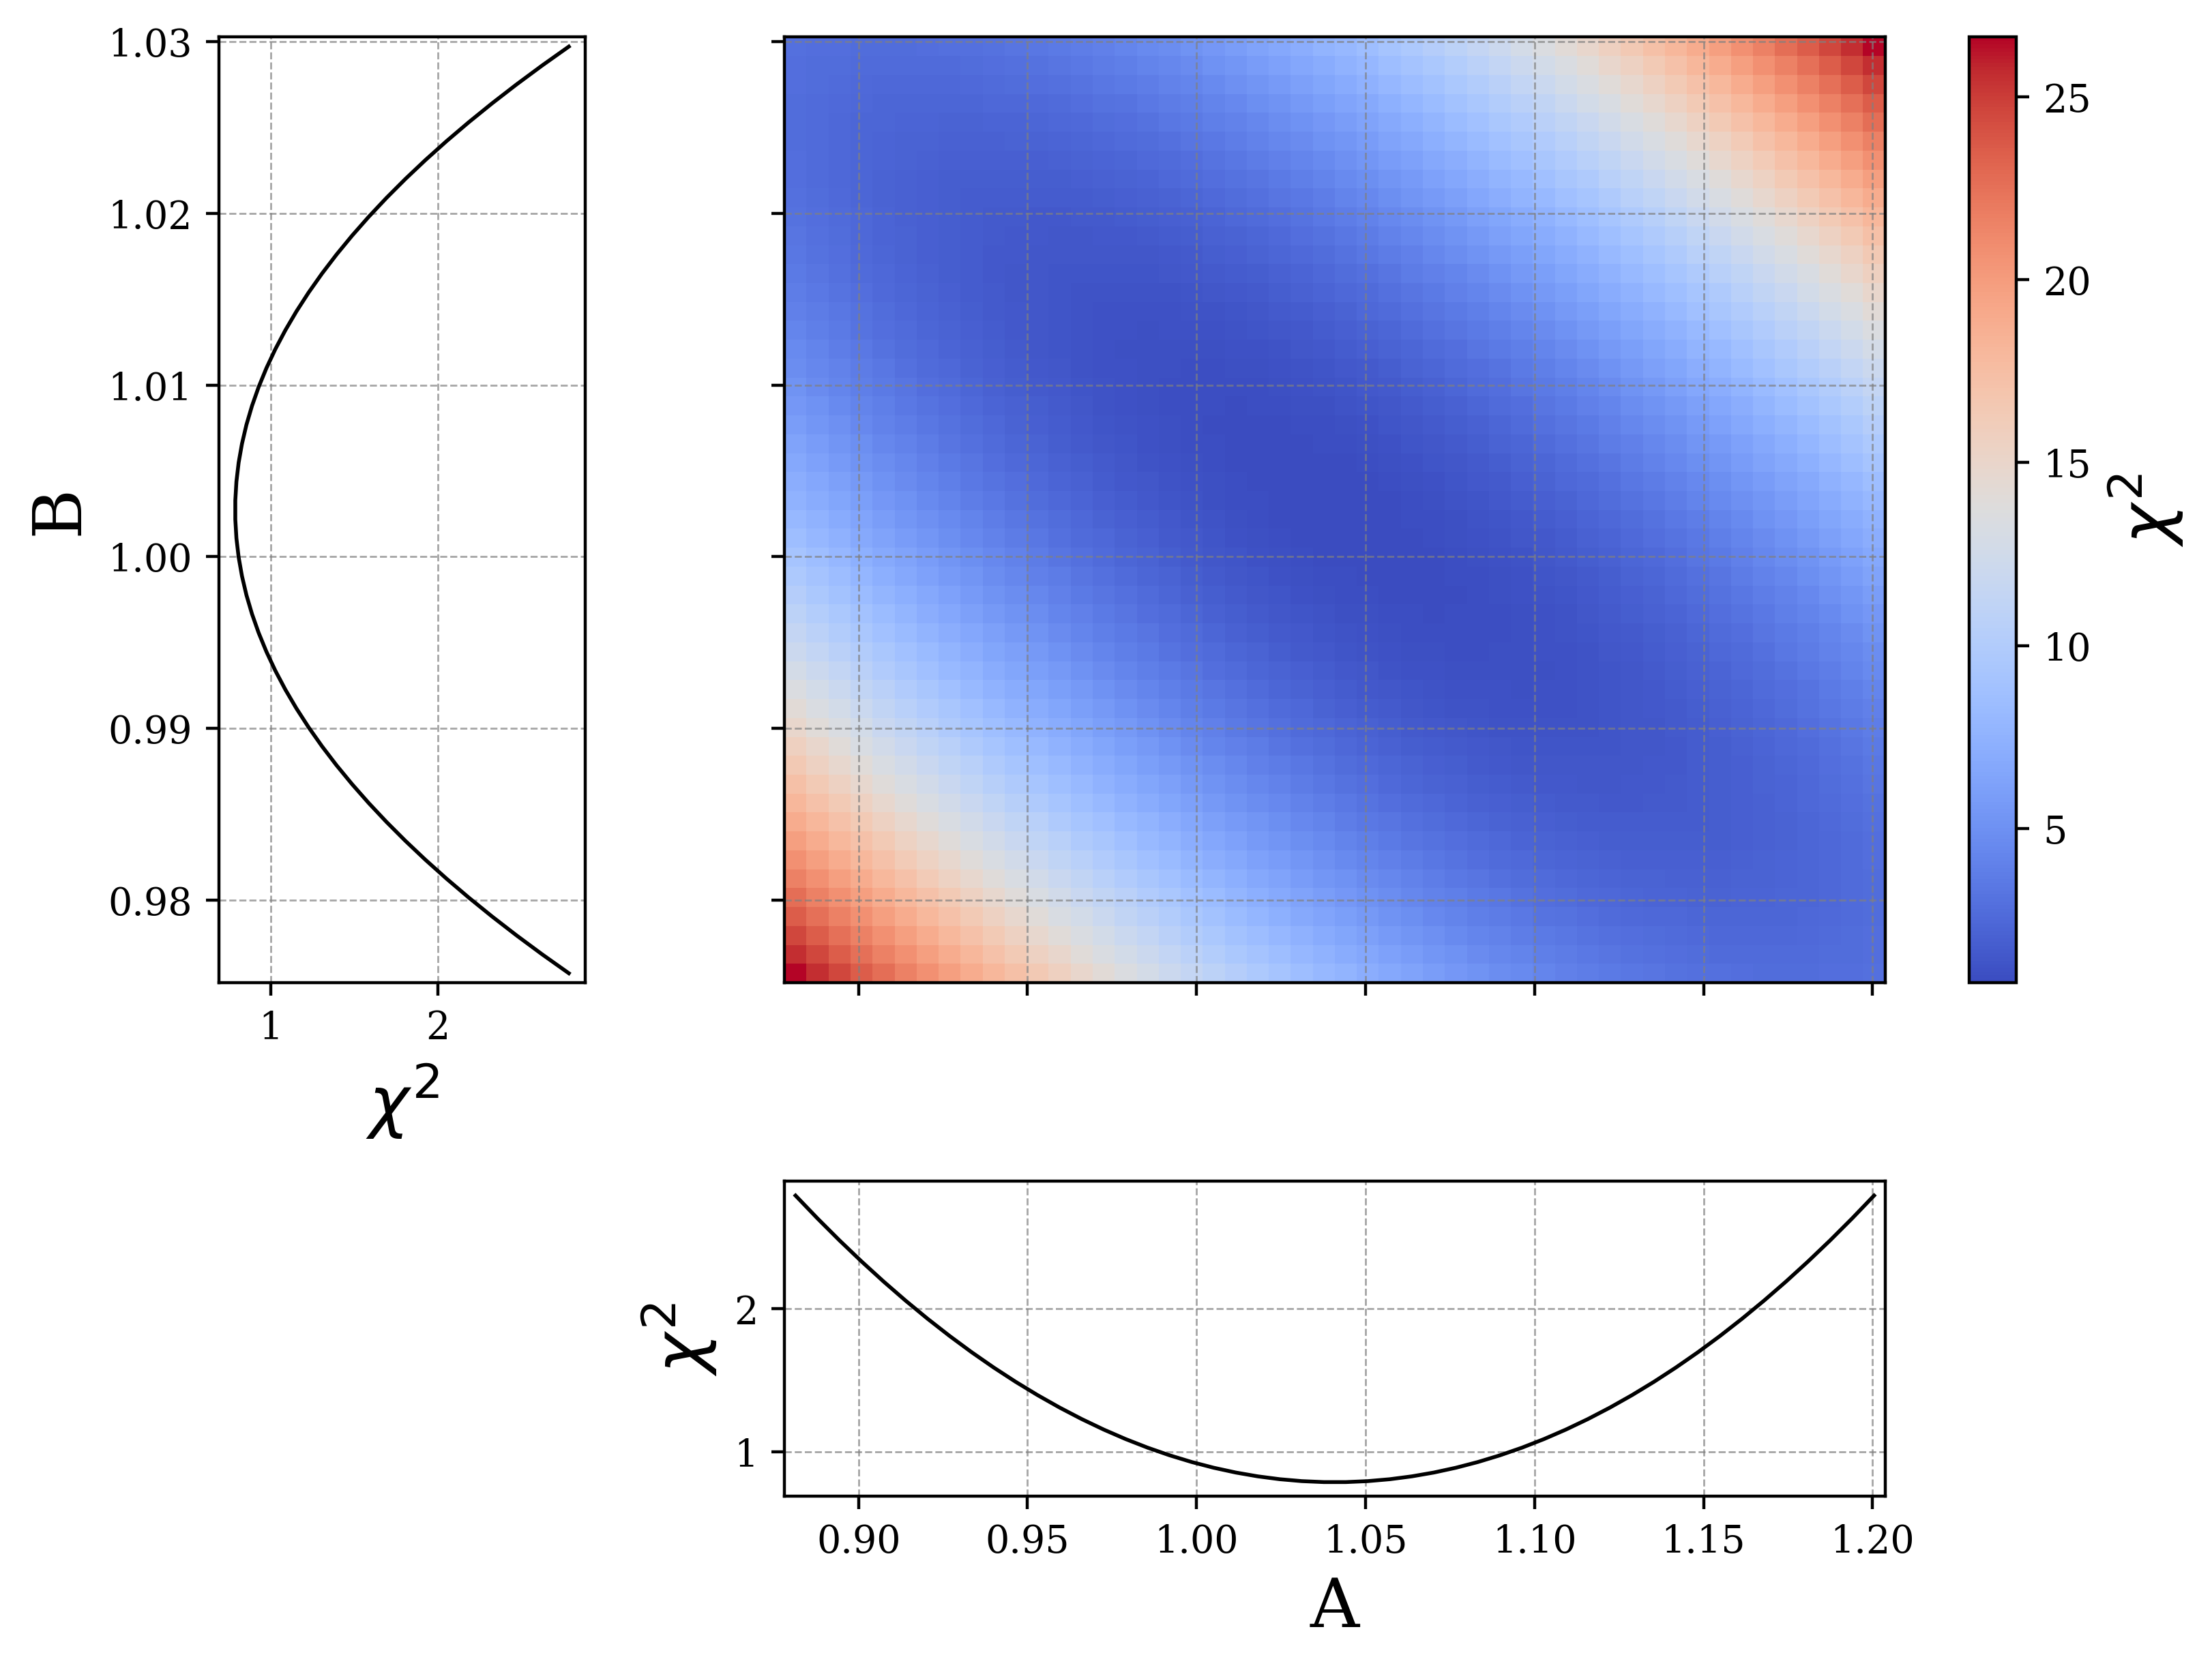

In [ ]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(8, 6), constrained_layout=True)

gs = gridspec.GridSpec(
    2, 2,
    height_ratios=[3, 1],
    width_ratios=[1, 3],
    figure=fig
)

ax_main = fig.add_subplot(gs[0, 1])  # 2D chi2 map
ax_b = fig.add_subplot(gs[0, 0], sharey=ax_main)   # sinistra (1D)
ax_blank = fig.add_subplot(gs[1, 0]) # vuoto
ax_a = fig.add_subplot(gs[1, 1], sharex=ax_main)     # sotto (1D)

ax_blank.axis('off')

# =========================
# 2D χ² MAP
# =========================
c = ax_main.pcolormesh(A, B, CHI, shading='auto', cmap='coolwarm')
fig.colorbar(c, ax=ax_main, label=r"$\chi^2$")

ax_main.tick_params(axis='x', labelbottom=False)
ax_main.tick_params(axis='y', labelleft=False)

# =========================
# 1D projection B
# =========================
ax_b.plot(Z_B, b_range, color='black', lw=1)
ax_b.set_xlabel(r"$\chi^2$")
ax_b.set_ylabel("B")

# =========================
# 1D projection A
# =========================
ax_a.plot(a_range, Z_A, color='black', lw=1)
ax_a.set_xlabel("A")
ax_a.set_ylabel(r"$\chi^2$")

let.salva_grafico(fig, grafico_output2)